In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter

#### **1. ¿Cuáles son las Categorías más Rentables?**

###### 1.1 Carga de Datasets

In [ ]:
# Order_items
order_items = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datasets TFM/olist_order_items_dataset.csv')

# Products
products = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datasets TFM/olist_products_dataset.csv')

# Product_category_name_translation
product_category_name_translation = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datasets TFM/product_category_name_translation.csv')

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/datasets TFM/olist_order_items_dataset.csv'

###### 1.2 Merge

In [ ]:
df_items_products = pd.merge(order_items, products, on='product_id')
df_items_products = pd.merge(df_items_products, products_eng, on='product_category_name')

###### 2. Análisis de Rentabilidad

In [ ]:
# Agrupamos por la categoría de producto y sumamos precio
revenue_per_category = df.groupby("product_category_name_english")["price"].sum()
print(revenue_per_category)

# Top 10
top_10_categories = revenue_per_category.sort_values(ascending=False).head(10)

###### 3. Representación Gráfica

In [ ]:
# Preparar colores usando la paleta Spectral
colors = plt.cm.Spectral_r(np.linspace(0, 1, len(top_10_categories)))

# Graficar
plt.figure(figsize=(10, 6))
top_10_categories.sort_values().plot(kind='barh', color=colors)
plt.xlabel("Revenue (R$)")
plt.title("Top 10 categorías por ingresos")
plt.tight_layout()
plt.show()

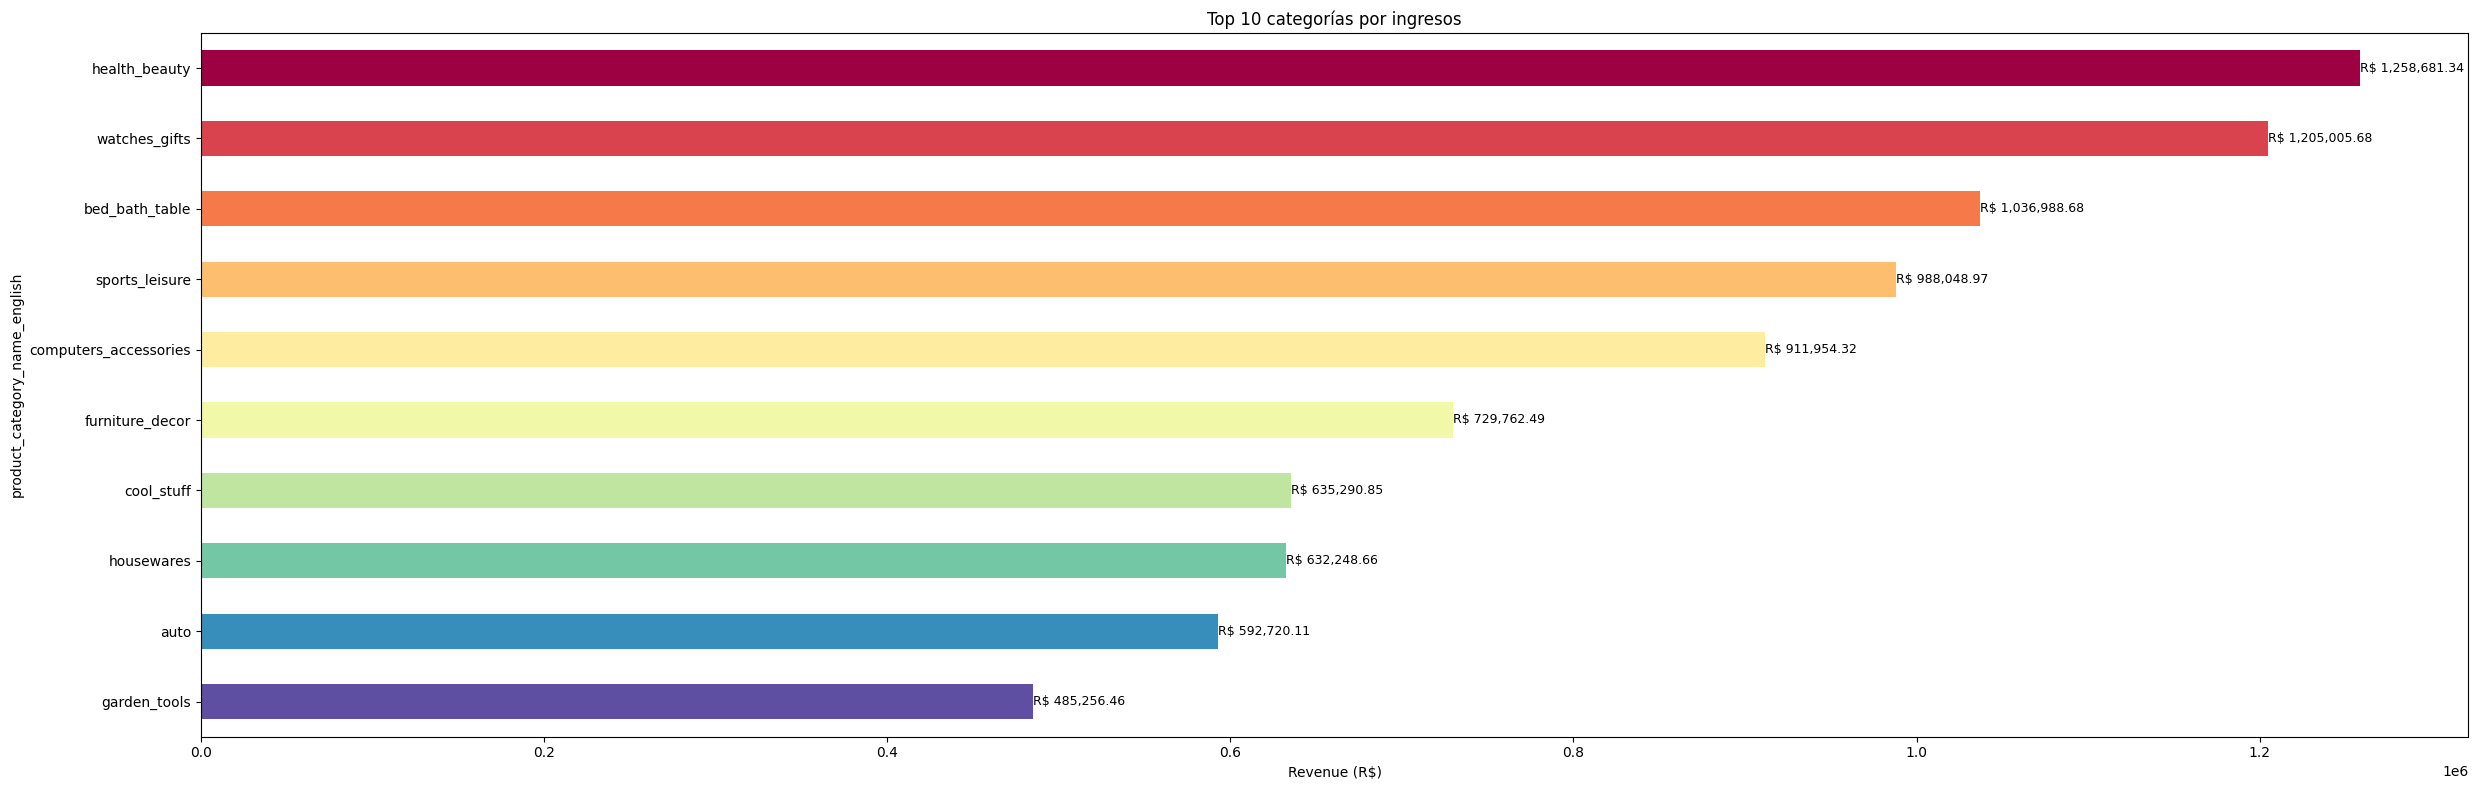

Si bien en la gráfica anterior podemos ver el volumen de ventas, no disponemos de la información del margen de cada categoría. Sería muy interesante disponer de esta información en futuros análisis para, en base al margen, apostar por unos productos u otros.

#### **2. ¿Qué tipo de productos se entregan más rápido o más lento?**

##### 2.1 Importación librerías

In [ ]:
# Revisar coincidencias difusas entre cadenas de texto
#!pip install geopandas plotly shapely folium fuzzywuzzy python-Levenshtein
#!pip install pandas gradio matplotlib openai tqdm

# Util cuando ciertas advertencias no son críticas y o queremos que aparezcan en la salida
import warnings
warnings.filterwarnings('ignore')

# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización de datos
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px

# Datos geoespaciales
#import geopandas as gpd
#from shapely.geometry import shape
#import folium

# Utilidades y manejo de archivos
import glob
import os

# Autorización para que GoogleColab acceda a Drive
from google.colab import drive
drive.mount('/content/drive')

# Opciones de visualización de pandas
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Establecer paleta de colores global usando 'viridis'
sns.set_palette("viridis")

# Para poder extraer un color base de esa paleta:
base_color = sns.color_palette("viridis")[0]

Mounted at /content/drive


##### 2.2 Importación dataset y formato de columnas

In [ ]:
# Para responder a estas preguntas utilizaremos el arhicvo 1_df_merge.csv que contiene todas las tablas

df_merge = pd.read_csv("/content/drive/MyDrive/nuclio/TFM NUCLIO/TFM Olist Ecommerce FINAL/03. Datasets Merged/1_df_merge.csv")



In [ ]:
# Revisamos el formato de los campos que contiene el archivo
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102425 entries, 0 to 102424
Data columns (total 48 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   order_id                           102425 non-null  object 
 1   ord_customer_id                    102425 non-null  object 
 2   ord_order_status                   102425 non-null  object 
 3   ord_order_purchase_timestamp       102425 non-null  object 
 4   ord_order_approved_at              102411 non-null  object 
 5   ord_order_delivered_carrier_date   101397 non-null  object 
 6   ord_order_delivered_customer_date  100195 non-null  object 
 7   ord_order_estimated_delivery_date  102425 non-null  object 
 8   ord_purchase_to_approval_days      102411 non-null  float64
 9   ord_approval_to_carrier_days       101383 non-null  float64
 10  ord_carrier_to_customer_days       100194 non-null  float64
 11  ord_purchase_to_delivery_days      1001

##### 2.3 Tiempos de procesamiento y envio

In [ ]:
# Conversión en formato fecha

df_merge['ord_order_purchase_timestamp'] = pd.to_datetime(df_merge['ord_order_purchase_timestamp'])
df_merge['ord_order_approved_at'] = pd.to_datetime(df_merge['ord_order_approved_at'])
df_merge['ord_order_delivered_carrier_date'] = pd.to_datetime(df_merge['ord_order_delivered_carrier_date'])
df_merge['ord_order_delivered_customer_date'] = pd.to_datetime(df_merge['ord_order_delivered_customer_date'])
df_merge['ord_order_estimated_delivery_date'] = pd.to_datetime(df_merge['ord_order_estimated_delivery_date'])

df_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102425 entries, 0 to 102424
Data columns (total 48 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   order_id                           102425 non-null  object        
 1   ord_customer_id                    102425 non-null  object        
 2   ord_order_status                   102425 non-null  object        
 3   ord_order_purchase_timestamp       102425 non-null  datetime64[ns]
 4   ord_order_approved_at              102411 non-null  datetime64[ns]
 5   ord_order_delivered_carrier_date   101397 non-null  datetime64[ns]
 6   ord_order_delivered_customer_date  100195 non-null  datetime64[ns]
 7   ord_order_estimated_delivery_date  102425 non-null  datetime64[ns]
 8   ord_purchase_to_approval_days      102411 non-null  float64       
 9   ord_approval_to_carrier_days       101383 non-null  float64       
 10  ord_carrier_to_custo

Revisamos la cantidad de pedidos que hay por status


In [ ]:
# Contar la cantidad de pedidos por estado
order_status_counts = df_merge['ord_order_status'].value_counts().reset_index()
order_status_counts.columns = ['order_status', 'count']
print (order_status_counts)

  order_status   count
0    delivered  100196
1      shipped    1127
2     canceled     465
3     invoiced     322
4   processing     306
5  unavailable       7
6     approved       2


Comparamos la fecha de recepción vs la fecha estimada de entrega de aquellos pedidos cuyo status es **delivered**

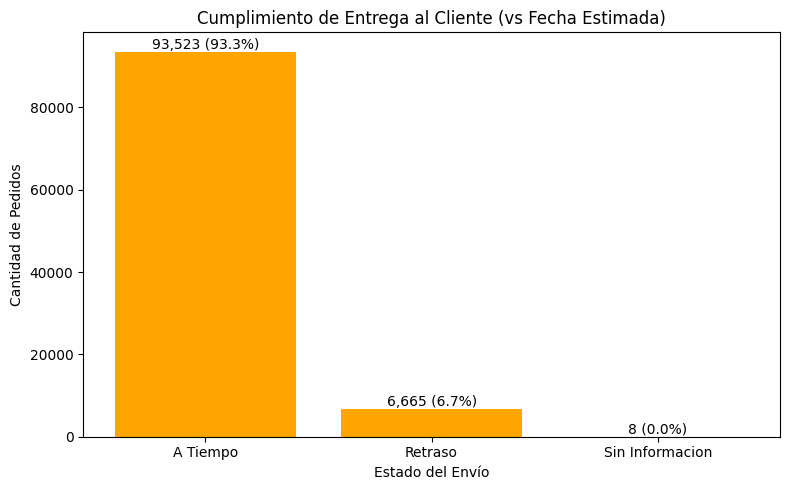

In [ ]:
# Consideramos el campo "ord_delay_vs_estimated_days" que contiene la diferencia en días entre
# ord_order_estimated_delivery_date - ord_order_delivered_customer_date


# Filtrar solo pedidos entregados
df_entregados = df_merge[df_merge['ord_order_status'] == 'delivered'].copy()

# Definimos una función para manejar valores nulos y clasificación de los pedidos.
def clasificar_envio(x):
    if pd.isnull(x):
        return 'Sin Informacion'
    elif x <= 0:
        return 'A Tiempo'
    else:
        return 'Retraso'

df_entregados['estado_envio'] = df_entregados['ord_delay_vs_estimated_days'].apply(clasificar_envio)

# Contar y calcular porcentaje
resumen_envios_cliente = df_entregados['estado_envio'].value_counts().reset_index()
resumen_envios_cliente.columns = ['estado_envio', 'cantidad']
total_pedidos = resumen_envios_cliente['cantidad'].sum()
resumen_envios_cliente['porcentaje'] = (
    resumen_envios_cliente['cantidad'] / total_pedidos * 100
)

# Crear gráfico sin paleta personalizada
plt.figure(figsize=(8, 5))
bars = plt.bar(
    resumen_envios_cliente['estado_envio'],
    resumen_envios_cliente['cantidad'],
    color='orange'
)
plt.title('Cumplimiento de Entrega al Cliente (vs Fecha Estimada)')
plt.xlabel('Estado del Envío')
plt.ylabel('Cantidad de Pedidos')

# Mostrar texto sobre las barras
for i, bar in enumerate(bars):
    cantidad = resumen_envios_cliente.loc[i, 'cantidad']
    porcentaje = resumen_envios_cliente.loc[i, 'porcentaje']
    texto = f'{cantidad:,} ({porcentaje:.1f}%)'
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        texto,
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()



##### 2.4 Categorías con mayor porcentaje de entregas con restraso (top 10)

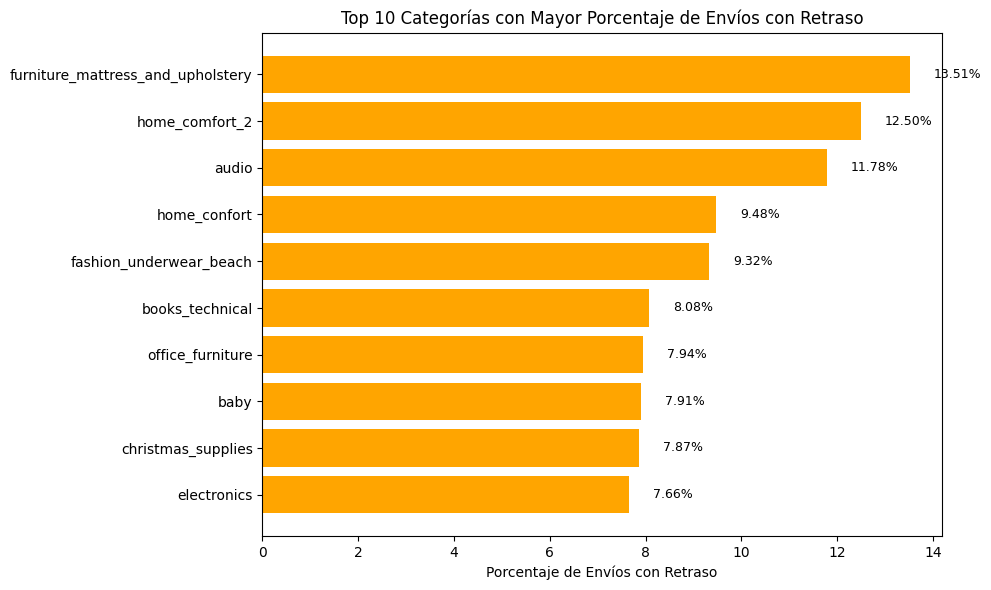

In [ ]:
# Visualizar el top 10 de categorías con más retrasos

# Agrupar por categoría de producto y estado del envío
envios_por_categoria = df_entregados.groupby(['pro_product_category_name_english', 'estado_envio']).size().unstack(fill_value=0)

# Calcular total y porcentaje de retrasos
envios_por_categoria['Total'] = envios_por_categoria.sum(axis=1)
envios_por_categoria['Porcentaje_Retraso'] = envios_por_categoria.get('Retraso', 0) / envios_por_categoria['Total'] * 100

# Obtener top 10 categorías con mayor porcentaje de retrasos
top_10_retraso = envios_por_categoria.sort_values(by='Porcentaje_Retraso', ascending=False).head(10)

# Preparar datos para el gráfico
top_10_retraso_sorted = top_10_retraso.sort_values(by='Porcentaje_Retraso', ascending=True)

# Crear gráfico de barras horizontales
plt.figure(figsize=(10, 6))
bars = plt.barh(top_10_retraso_sorted.index, top_10_retraso_sorted['Porcentaje_Retraso'], color='orange')
plt.xlabel('Porcentaje de Envíos con Retraso')
plt.title('Top 10 Categorías con Mayor Porcentaje de Envíos con Retraso')

# Añadir texto en las barras
for bar in bars:
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()



Si bien este gráfico indica que el 13.5% de la categoria forniture_mattress_and_upholstery se entregaron tarde tenemos que ver el volumen de envíos

En el siguiente gráfico aplicaremos un filtro que considere solo aquellas categorias que tienen más de 500 envios

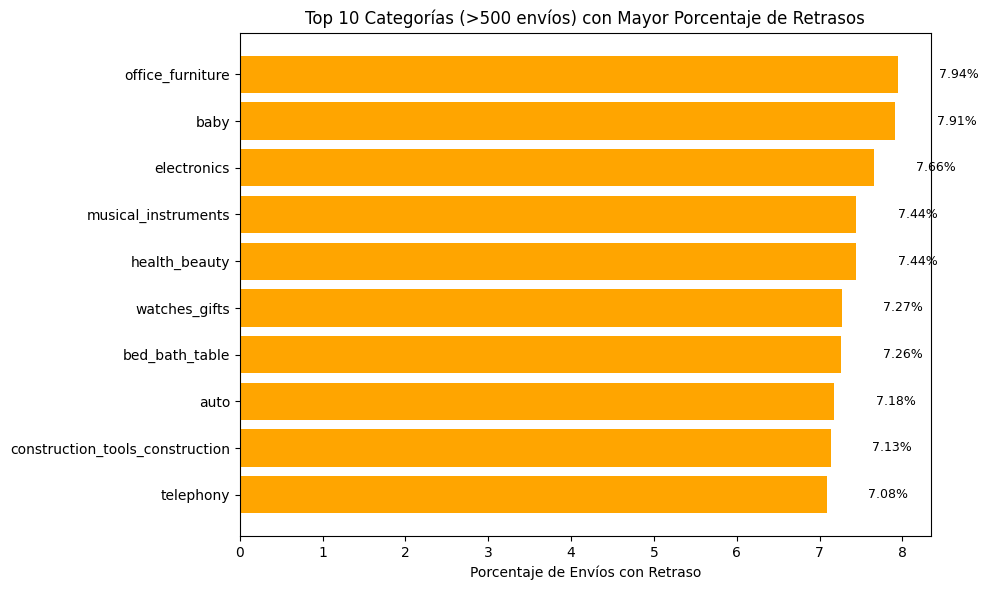

In [ ]:
# Filtrar categorías con más de 500 envíos
categorias_con_mas_de_500 = envios_por_categoria[envios_por_categoria['Total'] > 500]

# Calcular el top 10 de esas categorías con mayor porcentaje de retraso
top_10_retraso_500 = categorias_con_mas_de_500.sort_values(by='Porcentaje_Retraso', ascending=False).head(10)

# Ordenar para visualización en gráfico
top_10_retraso_500_sorted = top_10_retraso_500.sort_values(by='Porcentaje_Retraso', ascending=True)

# Crear gráfico de barras horizontales
plt.figure(figsize=(10, 6))
bars = plt.barh(top_10_retraso_500_sorted.index, top_10_retraso_500_sorted['Porcentaje_Retraso'], color='orange')
plt.xlabel('Porcentaje de Envíos con Retraso')
plt.title('Top 10 Categorías (>500 envíos) con Mayor Porcentaje de Retrasos')

# Añadir texto en las barras
for bar in bars:
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()


##### 2.5 Categorías con mayor porcentaje de entregas a tiempo (top 10)

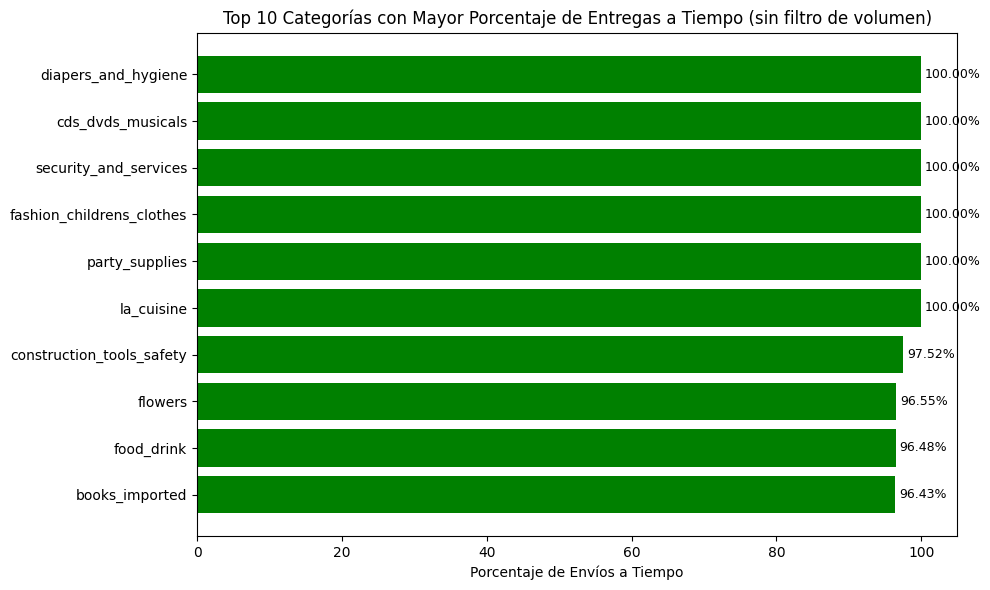

In [ ]:
# Calcular porcentaje de entregas a tiempo por categoría
envios_por_categoria['Porcentaje_A_Tiempo'] = envios_por_categoria.get('A Tiempo', 0) / envios_por_categoria['Total'] * 100

# Obtener top 10 categorías con mayor porcentaje de entregas a tiempo (sin filtrar por volumen)
top_10_atiempo_all = envios_por_categoria.sort_values(by='Porcentaje_A_Tiempo', ascending=False).head(10)

# Ordenar para visualización
top_10_atiempo_all_sorted = top_10_atiempo_all.sort_values(by='Porcentaje_A_Tiempo', ascending=True)

# Crear gráfico de barras horizontales
plt.figure(figsize=(10, 6))
bars = plt.barh(top_10_atiempo_all_sorted.index, top_10_atiempo_all_sorted['Porcentaje_A_Tiempo'], color='green')
plt.xlabel('Porcentaje de Envíos a Tiempo')
plt.title('Top 10 Categorías con Mayor Porcentaje de Entregas a Tiempo (sin filtro de volumen)')

# Añadir texto en las barras
for bar in bars:
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()


En el siguiente gráfico aplicaremos un filtro que considere solo aquellas categorias que tienen más de 500 envios

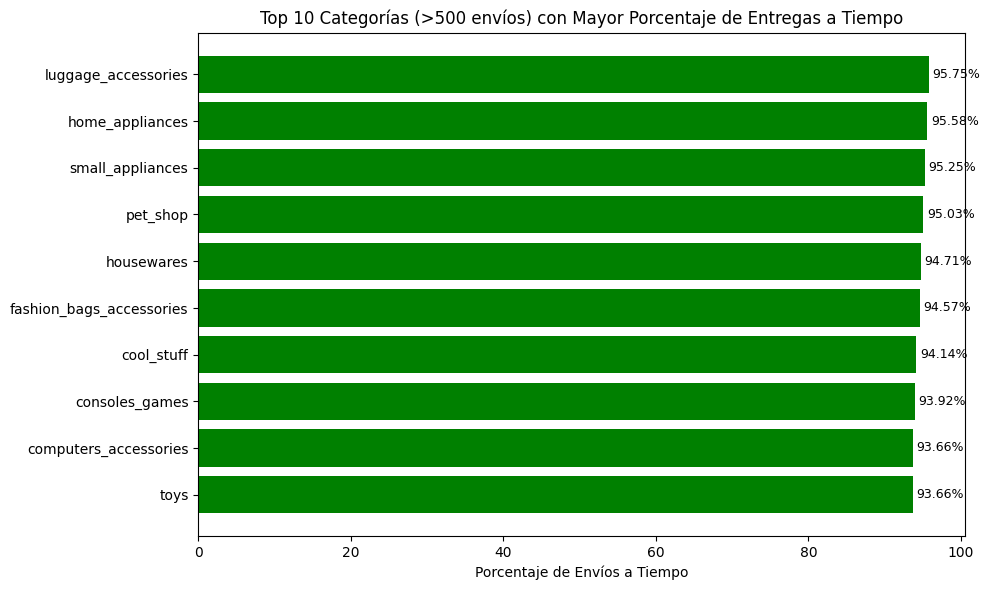

In [ ]:
# Calcular porcentaje de entregas a tiempo por categoría
envios_por_categoria['Porcentaje_A_Tiempo'] = envios_por_categoria.get('A Tiempo', 0) / envios_por_categoria['Total'] * 100

# Filtrar categorías con más de 500 envíos
categorias_con_mas_de_500 = envios_por_categoria[envios_por_categoria['Total'] > 500]

# Obtener top 10 categorías con mayor porcentaje de entregas a tiempo
top_10_atiempo_500 = categorias_con_mas_de_500.sort_values(by='Porcentaje_A_Tiempo', ascending=False).head(10)

# Ordenar para visualización
top_10_atiempo_500_sorted = top_10_atiempo_500.sort_values(by='Porcentaje_A_Tiempo', ascending=True)

# Crear gráfico de barras horizontales
plt.figure(figsize=(10, 6))
bars = plt.barh(top_10_atiempo_500_sorted.index, top_10_atiempo_500_sorted['Porcentaje_A_Tiempo'], color='green')
plt.xlabel('Porcentaje de Envíos a Tiempo')
plt.title('Top 10 Categorías (>500 envíos) con Mayor Porcentaje de Entregas a Tiempo')

# Añadir texto en las barras
for bar in bars:
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()





#### **3. ¿Qué métodos de pago son más utilizados?**



In [ ]:
df_payments = pd.read_csv("/content/drive/MyDrive/nuclio/TFM NUCLIO/TFM Olist Ecommerce FINAL/01. Archivos CSV Limpios/df_payments_clean.csv")


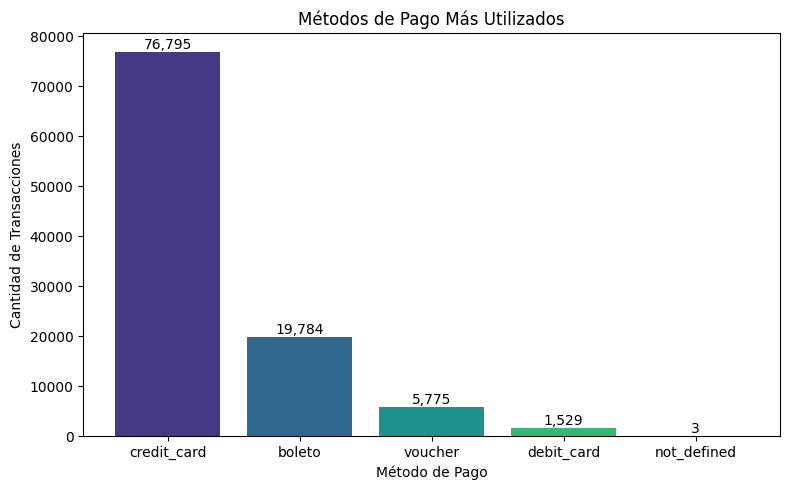

In [ ]:
# Contar métodos de pago
metodos_pago = (
    df_payments['payment_type']
    .value_counts()
    .reset_index()
)
metodos_pago.columns = ['metodo_pago', 'cantidad']  # Renombrar columnas correctamente

# Colores viridis
viridis_colors = sns.color_palette("viridis", n_colors=len(metodos_pago))

# Graficar
plt.figure(figsize=(8, 5))
bars = plt.bar(metodos_pago['metodo_pago'], metodos_pago['cantidad'], color=viridis_colors)
plt.title('Métodos de Pago Más Utilizados')
plt.xlabel('Método de Pago')
plt.ylabel('Cantidad de Transacciones')

# Añadir etiquetas
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{int(yval):,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


#### **4. ¿Hay relación entre tiempo de entrega y la calificación del cliente?**

##### Carga de Datos

In [ ]:
## Cargamos los datasets

# Orders
df_orders = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datasets TFM/olist_orders_datasets_clean V2.csv')

# Reviews
df_reviews = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datasets TFM/olist_reviews_dataset_clean V2.csv')

## Hacemos Merge de los dos DataFrames

df_orders_reviews = pd.merge(df_orders, df_reviews, on='order_id', how="inner")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/datasets TFM/olist_orders_dataset.csv'

##### Representación Gráfica

###### Boxplot

In [ ]:
variables = ['carrier_to_customer_days', 'purchase_to_delivery_days', 'delay_vs_estimated_days']

variables = ['delay_vs_estimated_days']

for var in variables:
    # Calculamos los límites del IQR para la variable actual
    Q1 = df_orders_reviews[var].quantile(0.25)
    Q3 = df_orders_reviews[var].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Filtramos los Outliers
    df_filtrado = df_orders_reviews[(df_orders_reviews[var] >= limite_inferior) & (df_orders_reviews[var] <= limite_superior)]

    # Graficamos el boxplot
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df_filtrado, x='review_score', y=var)
    plt.title("Días de Retraso por Review Score")
    plt.xlabel('Review Score')
    plt.ylabel("Días de Retraso")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

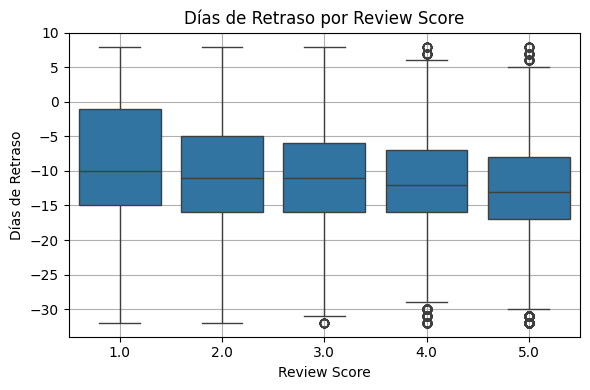

Los pedidos con una puntuación de 1, su mediana tiende a ser más alta que las demás, es decir, los pedidos tardaron más en llegar; para los pedidos con puntuación 2-3, el retraso es menor y su mediana está ligeramente más baja que los anteriores. En cambio para los pedidos con puntuaciones de 4-5 la mediana es más baja, por lo que los pedidos se han entregado antes de tiempo.

###### Correlación de Spearman Delay_vs_estimated_days y Review Score

In [ ]:
from scipy.stats import spearmanr

# Filtrar el DataFrame para eliminar filas con valores nulos
filtered_df = df_orders_reviews[["review_score", "delay_vs_estimated_days"]].dropna()

# Calcular la correlación de Spearman y el p-valor
spearman_corr, spearman_pval = spearmanr(
    filtered_df["review_score"],
    filtered_df["delay_vs_estimated_days"]
)

# Mostrar resultados
print(f"Spearman Correlation: {spearman_corr:.3f}")
print(f"P-value: {spearman_pval:.3e}")

Escogimos la correlación de Spearman se eligió porque las variables consideradas —retraso de entrega y puntaje de reseña— no necesariamente siguen una distribución normal ni tienen una relación lineal.

El coeficiente obtenido (-0.1761) indica una relación negativa débil pero consistente: cuando el pedido llega más tarde de lo estimado, el cliente tiende a calificar con menor puntuación.

A pesar de la debilidad de la relación, el valor p extremadamente bajo (< 0.001) demuestra que esta tendencia es estadísticamente significativa y no es producto del azar.

Esto sugiere que la puntualidad en la entrega influye en la satisfacción del cliente, aunque pueden intervenir otros factores adicionales.

#### **5. ¿Qué estados generan más ventas?**

In [ ]:
#cargar datasets
customers = pd.read_csv("olist_customers_dataset (1).csv")
orders = pd.read_csv("olist_orders_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")


LIMPIEZA DE DATA SETS

In [ ]:

#eliminar duplicados
customers = customers.drop_duplicates()
orders = orders.drop_duplicates()
order_items = order_items.drop_duplicates()

#Eliminar filas sin clave primaria
customers = customers.dropna(subset=["customer_id"])
orders = orders.dropna(subset=["order_id", "customer_id"])
order_items = order_items.dropna(subset=["order_id", "price"])

#Convertir tipos de fecha y númericos
#-orders : varias columnas datetime
date_cols_orders = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for col in date_cols_orders:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")


#- order_items: shipping_limit_date
order_items["shipping_limit_date"] = pd.to_datetime(order_items["shipping_limit_date"],
                                                     errors="coerce")

# - price y freight_value a float
order_items["price"]         = pd.to_numeric(order_items["price"], errors="coerce")
order_items["freight_value"] = pd.to_numeric(order_items["freight_value"],
                                             errors="coerce")


#Comprobar y eliminar valores faltantes críticos
#(por ejemplo, si price es NaN)
order_items = order_items.dropna(subset=["price"])
orders      = orders.dropna(subset=["customer_id"])
customers   = customers.dropna(subset=["customer_state"])


#Reiniciar índices
customers   = customers.reset_index(drop=True)
orders      = orders.reset_index(drop=True)
order_items = order_items.reset_index(drop=True)

MERGE DATA SETS Y AGRUPAR DATOS

In [ ]:
# order_items + orders (por order_id)
order_items_orders = pd.merge(order_items, orders, on="order_id", how="left")

# + customers (por customer_id)
full_data = pd.merge(order_items_orders, customers, on="customer_id", how="left")

In [ ]:
#agrupar y ordenar
sales_by_state = (
    full_data.groupby("customer_state")["price"]
    .sum()
    .reset_index()
    .sort_values(by="price", ascending=False)
)

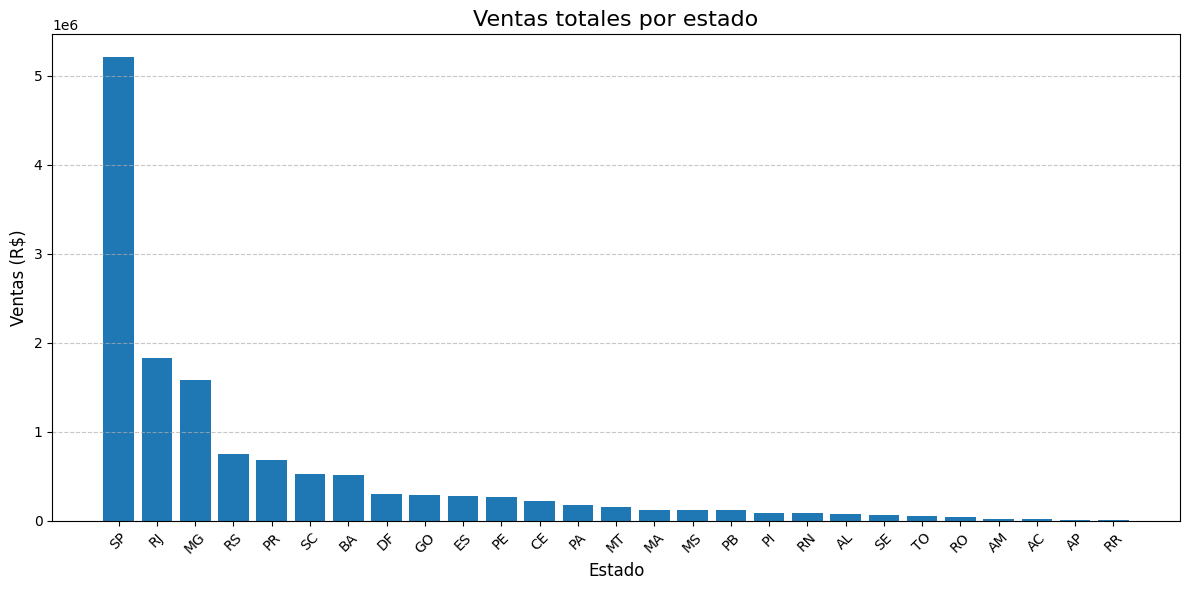

In [ ]:
#visualizar los cambios
plt.figure(figsize=(12, 6))
plt.bar(sales_by_state["customer_state"], sales_by_state["price"])
plt.title("Ventas totales por estado", fontsize=16)
plt.xlabel("Estado", fontsize=12)
plt.ylabel("Ventas (R$)", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## CONCLUSIONES

El estado de Sao Paulo (SP) es el que mas ventas genera, después Rio de Janeiro (RJ) y Minas Gerais (MG).

Esto permite enfocar estrategias comerciales, marketing o expansión en los estados más rentables.

Esto se puede deber a la cantidad de personas que viven siendo las ciudades con mayor población o mayor PIB.

-Data set de customers: tiene el estado (customer_state) de cada cliente
-Orders : enlaza pedidos con clientes.
-order_items: contiene el precio de cada producto vendido (la base para calcular las ventas).

-Unidos los DS: precios con los pedidos usando (order_items) con (orders) usando el order_id.
-Luego unimos esta tabla con los clientes (customers) usando customer_id.
-La tabla nos va a mosrar una tabla con precio de cada producto y el estado del cliente.

-Agrupamos los datos por customer_state.
-Sumamos los precios (price) de todos los productos vendidos en cada estado y ordenamos los resultados de mayor a menor.



#### **6. ¿Qué días o meses tienen mayor volumen de ventas?**

In [ ]:
# Extraemos el mes de order_purchase_timestamp
df_orders["order_month"] = df_orders["order_purchase_timestamp"].dt.to_period("M")

# Agrupamos por Mes y hacemos un Count
monthly_orders = df_orders.groupby("order_month")["order_id"].count()
monthly_orders = monthly_orders.sort_values(ascending=False)

# Convertimos a String el índice
monthly_orders.index = monthly_orders.index.astype(str)

# Representación Gráfico de Barras de forma Descendente
plt.figure(figsize=(12, 6))
monthly_orders.plot(kind="bar")
plt.title("Número de Pedidos por Mes")
plt.xlabel("Mes")
plt.ylabel("Cantidad de Pedidos")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

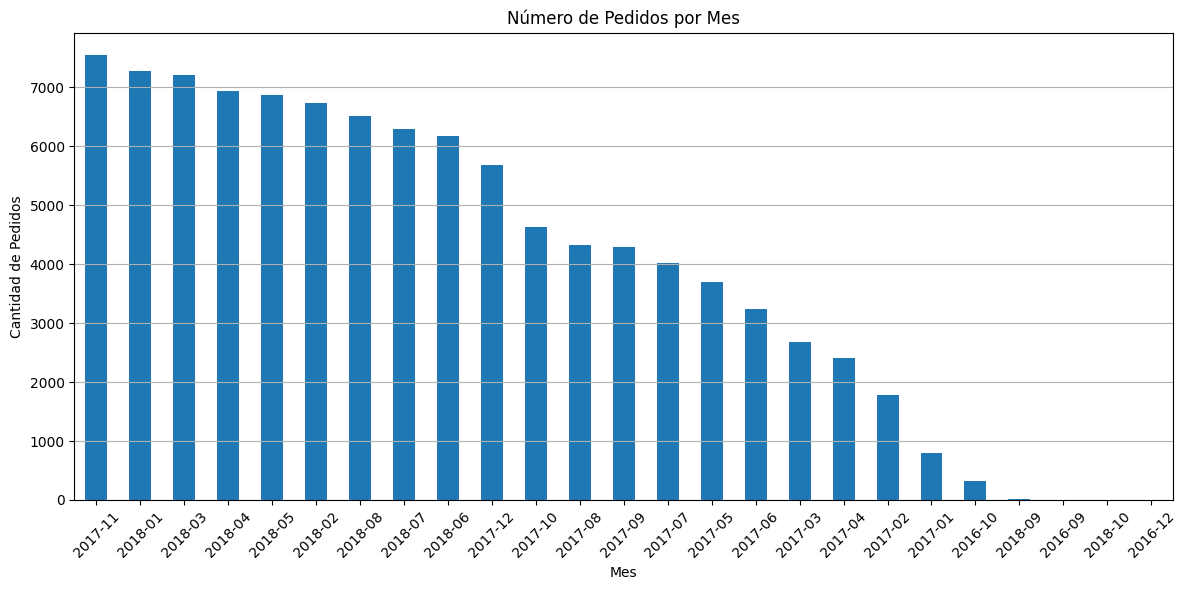

**Hechos socioeconómicos y políticos que han podido influir:**

**Septiembre 2016** - En septiembre de 2016, la presidenta del país Dilma Rousseff fue destituida al ser acusada de maniobras fiscales ilegales. En su lugar, el vicepresidente Michel Temer, que ya ejercía como presidente interino desde Mayo de 2016, asumió el cargo pero su gobierno fue recibido con controversia y protestas en las calles lo cuál explicaría los datos anómalos que se muestran anteriormente en nuestro gráfico.

**Octubre 2018** - Bolsonaro gana las elecciones presidenciales en Brasil. Se establece un clima de preocupación en la sociedad brasileña debido a su discurso autoritario. El país vive inmerso en una incertidumbre electoral, lo que lleva a un frenazo en la economía, impactando también en el e-commerce.

**Diciembre 2016** - En Diciembre de 2016, Brasil seguía en una profunda recesión económica, con caída del PIB 3,3% tras un descenso del mismo 3,5% en 2015, desempleo en torno al 12% y muy baja confianza del consumidor. La crisis política tras el impeachment de Dilma Rousseff también afectó el clima de consumo. Como resultado, las ventas online en plataformas como Olist fueron más bajas, incluso en plena temporada navideña.

